In [3]:
import filegetter.filegetter as fgt
import pandas as pd
df_240228 = fgt.get("binance", "swap", "btc-usdt", "trade","20240228", machine="AWS-JP1")
df_240302 = fgt.get("binance", "swap", "btc-usdt", "trade","20240302", machine="AWS-JP1")
df_240320 = fgt.get("binance", "swap", "btc-usdt", "trade","20240320", machine="AWS-JP1")
df_241106 = fgt.get("binance", "swap", "btc-usdt", "trade","20241106", machine="AWS-JP1")



loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_02_28.hdf 


loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_02.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_20.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_11_06.hdf 


In [12]:
df_240228

,p,v,ts,local_time,upload_time,source,trade_id
0,57074.4,-0.015,1709078397784,1709078397786613523,1709078397786624777,35.73.76.122:443,2034867125
1,57074.4,-0.001,1709078397935,1709078397935596655,1709078397935609233,35.73.76.122:443,2034867126
2,57074.5,0.059,1709078398367,1709078398369927284,1709078398369941954,35.73.76.122:443,2034867127
3,57074.4,-0.041,1709078398518,1709078398519586512,1709078398519593703,52.68.112.64:443,2034867128
4,57074.5,0.002,1709078399110,1709078399111804078,1709078399111816413,52.68.112.64:443,2034867129
...,...,...,...,...,...,...,...
4129635,62487.8,-0.089,1709164797013,1709164797014084966,1709164797014159993,54.178.234.202:443,2038997733
4129636,62487.9,0.003,1709164797013,1709164797015436317,1709164797015464014,54.178.234.202:443,2038997734
4129637,62487.8,-0.001,1709164797164,1709164797165616318,1709164797165624290,35.73.76.122:443,2038997735
4129638,62487.9,0.002,1709164797473,1709164797474512982,1709164797474522280,54.178.234.202:443,2038997736


In [16]:
df_240302

,p,v,ts,local_time,upload_time,source,trade_id
0,102884.2,0.001,1747061513557,1718551359157440092,1718550921660331956,NaN,6292943388
1,102884.2,0.008,1747061513571,1717522068657141796,1717521297044595104,NaN,6292943389
2,102884.2,0.003,1747061513641,1712583156646550120,1712580497987653300,NaN,6292943390
3,102884.2,0.004,1747061513641,1712582757188406232,1712580497987653300,NaN,6292943391
4,102884.2,0.001,1747061513641,1712582464984455348,1712580497987653300,NaN,6292943392
5,102884.2,0.274,1747061513641,1712581428030525316,1712580497987653300,NaN,6292943393
6,102884.1,-0.052,1747061513662,1711087520846447232,1711083172983029800,NaN,6292943394
7,102884.1,-0.005,1747061513662,1711087075996446520,1711083172983029800,NaN,6292943395
8,102884.1,-0.006,1747061513662,1711086756047580992,1711083172983029800,NaN,6292943396
9,102880.0,-0.069,1747061513662,1711085900072846840,1711083172983029800,NaN,6292943397


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [4]:
import pandas as pd, numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import filegetter.filegetter as fgt   # 你已有的库

# ----------------------------- A. 评估函数 -----------------------------
def evaluate_volume_model(trades_df, halflife=30, lookahead=2):
    """
    对单日 trade 数据计算 EWM 预测 → 与未来 lookahead 秒真实成交量对比
    返回：dict 指标
    """
    # —— 0. 载入 & 预处理 ——
    trades_df = trades_df.copy()                      # 避免原地修改
    trades_df["datetime"] = pd.to_datetime(trades_df["ts"], unit="ms", utc=True)
    trades = (trades_df.set_index("datetime")
                         .sort_index())
    trades["vol"] = trades["v"].abs()

    # —— 1. 秒级聚合 ——
    vol_1s = trades["vol"].resample("1s").sum().fillna(0)

    # —— 2. 特征 & 标签 ——
    pred_vol = vol_1s.ewm(halflife=halflife, adjust=False).mean()
    true_vol = vol_1s.rolling(window=lookahead, min_periods=lookahead).sum().shift(-(lookahead-1))

    df_eval = pd.DataFrame({"pred": pred_vol, "true": true_vol}).dropna()

    # —— 3. 指标 ——
    mae  = mean_absolute_error(df_eval["true"], df_eval["pred"])
    rmse = mean_squared_error(df_eval["true"], df_eval["pred"], squared=False)
    mape = (np.abs(df_eval["true"] - df_eval["pred"]) /
            df_eval["true"].replace(0, np.nan)).mean()
    r2   = r2_score(df_eval["true"], df_eval["pred"])

    return {
        "samples": len(df_eval),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

In [ ]:
df_240302 = df_240302.dropna(subset=["p", "v", "ts"])


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [11]:
df_240302

,p,v,ts,local_time,upload_time,source,trade_id
0,102884.2,0.001,1747061513557,1718551359157440092,1718550921660331956,NaN,6292943388
1,102884.2,0.008,1747061513571,1717522068657141796,1717521297044595104,NaN,6292943389
2,102884.2,0.003,1747061513641,1712583156646550120,1712580497987653300,NaN,6292943390
3,102884.2,0.004,1747061513641,1712582757188406232,1712580497987653300,NaN,6292943391
4,102884.2,0.001,1747061513641,1712582464984455348,1712580497987653300,NaN,6292943392
5,102884.2,0.274,1747061513641,1712581428030525316,1712580497987653300,NaN,6292943393
6,102884.1,-0.052,1747061513662,1711087520846447232,1711083172983029800,NaN,6292943394
7,102884.1,-0.005,1747061513662,1711087075996446520,1711083172983029800,NaN,6292943395
8,102884.1,-0.006,1747061513662,1711086756047580992,1711083172983029800,NaN,6292943396
9,102880.0,-0.069,1747061513662,1711085900072846840,1711083172983029800,NaN,6292943397


In [33]:
dates = {
    "2024-02-28": df_240228,
    "2024-03-19": df_240319,
    "2024-03-20": df_240320,
    "2024-11-06": df_241106 
}
dates.items()

dict_items([('2024-02-28',                p      v             ts           local_time  \
0        57074.4 -0.015  1709078397784  1709078397786613523   
1        57074.4 -0.001  1709078397935  1709078397935596655   
2        57074.5  0.059  1709078398367  1709078398369927284   
3        57074.4 -0.041  1709078398518  1709078398519586512   
4        57074.5  0.002  1709078399110  1709078399111804078   
...          ...    ...            ...                  ...   
4129635  62487.8 -0.089  1709164797013  1709164797014084966   
4129636  62487.9  0.003  1709164797013  1709164797015436317   
4129637  62487.8 -0.001  1709164797164  1709164797165616318   
4129638  62487.9  0.002  1709164797473  1709164797474512982   
4129639  62487.8 -0.018  1709164797684  1709164797685598304   

                 upload_time              source    trade_id  
0        1709078397786624777    35.73.76.122:443  2034867125  
1        1709078397935609233    35.73.76.122:443  2034867126  
2        170907839836994195

In [34]:
results=[]
for day, df in dates.items():
    try:
        metrics = evaluate_volume_model(df, halflife=30, lookahead=2)
        metrics["date"] = day
        results.append(metrics)
        print(f"[OK ] {day:10s}  samples={metrics['samples']}")
    except ValueError as e:
        print(f"[ERR] {day:10s}  → {e}")

[OK ] 2024-02-28  samples=86400
[OK ] 2024-03-19  samples=86400
[OK ] 2024-03-20  samples=86399
[OK ] 2024-11-06  samples=86401


In [35]:
results = []
for day, df in dates.items():
    metrics = evaluate_volume_model(df)
    metrics["date"] = day
    results.append(metrics)

# 整理成 DataFrame 便于查看 / 保存
results_df = (pd.DataFrame(results)
                .set_index("date")
                .round({"MAE": 4, "RMSE": 4, "MAPE": 4, "R2": 4}))
print(results_df)


            samples      MAE     RMSE    MAPE      R2
date                                                 
2024-02-28    86400  14.6517  47.3979  2.3234  0.2827
2024-03-19    86400  10.6876  30.2601  1.0048  0.0641
2024-03-20    86399   9.7485  27.2237  0.9872  0.0970
2024-11-06    86401  10.6107  35.1780  1.1437  0.1484


In [5]:
plt.rcParams["figure.dpi"] = 120

In [6]:
fgt.get("binance", "swap", "btc-usdt", "trade","20240126", machine="AWS-JP1")


loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_26.hdf 


,39953.3,-0.171,1706227200079,1706227200081279935,1706227200081290158,13.113.229.36:443,1999893531
0,39953.4,0.167,1706227200131,1706227200133297993,1706227200133305725,52.68.233.140:443,1999893532
1,39953.3,-0.008,1706227200282,1706227200283668678,1706227200283709636,13.113.229.36:443,1999893533
2,39953.4,0.011,1706227203831,1706227203833055180,1706227203833065717,13.113.229.36:443,1999893534
3,39953.4,0.025,1706227204181,1706227204182923927,1706227204182934102,13.113.229.36:443,1999893535
4,39953.3,-0.13,1706227204185,1706227204186226177,1706227204186231370,13.113.229.36:443,1999893536
...,...,...,...,...,...,...,...
1213395,41808.2,0.882,1706313599229,1706313599231516212,1706313599231898276,13.113.229.36:443,2001106926
1213396,41808.1,-0.62,1706313599233,1706313599234384878,1706313599234459104,13.113.229.36:443,2001106927
1213397,41807.9,-0.022,1706313599233,1706313599235374335,1706313599235391554,13.113.229.36:443,2001106928
1213398,41807.6,-0.024,1706313599233,1706313599235639565,1706313599235651720,13.113.229.36:443,2001106929


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import filegetter.filegetter as fgt

lookahead = 2          # 先在循环外声明，保持一致
halflife  = 30

# ---------- your helpers copied verbatim ----------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_volume_model(trades_df, halflife=30, lookahead=2):
    trades_df = trades_df.copy()
    trades_df["datetime"] = pd.to_datetime(trades_df["ts"], unit="ms", utc=True)
    trades = trades_df.set_index("datetime").sort_index()
    trades["vol"] = trades["v"].abs()

    vol_1s = trades["vol"].resample("1s").sum().fillna(0)
    pred_vol = vol_1s.ewm(halflife=halflife, adjust=False).mean()
    true_vol = vol_1s.rolling(lookahead, min_periods=lookahead).sum().shift(-(lookahead-1))

    df_eval = pd.DataFrame({"pred": pred_vol, "true": true_vol}).dropna()

    return {
        "samples": len(df_eval),
        "MAE":  mean_absolute_error(df_eval["true"], df_eval["pred"]),
        "RMSE": mean_squared_error(df_eval["true"], df_eval["pred"], squared=False),
        "MAPE": (np.abs(df_eval["true"]-df_eval["pred"])/df_eval["true"].replace(0, np.nan)).mean(),
        "R2":   r2_score(df_eval["true"], df_eval["pred"])
    }

def daily_realized_vol(trades_df):
    if trades_df.empty:
        return np.nan
    trades_df = trades_df.copy()
    trades_df["datetime"] = pd.to_datetime(trades_df["ts"], unit="ms", utc=True)
    px = trades_df.set_index("datetime").sort_index()["p"].astype(float)

    px_1m = px.resample("1min").last().dropna()
    if len(px_1m) < 2:
        return np.nan
    log_ret = np.log(px_1m).diff().dropna()
    return log_ret.std(ddof=0) * np.sqrt(len(log_ret))   # √n σ1m

In [ ]:
# ---------------------------------------------------

results = []
dates   = pd.date_range("2024-01-01", "2024-06-22", freq="D")

for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        df = fgt.get("binance", "swap", "btc-usdt", "trade", ymd, machine="AWS-JP1")
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")
        continue

    # —— 1. 只保留三列并清洗 NaN ——
    cols = ["p", "v", "ts"]
    if not set(cols).issubset(df.columns):
        print(f"[SKIP] {ymd}: missing columns")
        continue
    df = df[cols].dropna(subset=cols)
    if df.empty:
        print(f"[SKIP] {ymd}: all rows dropped after NaN filter")
        continue

    # 🔹 2. 检查这一日有多少 “整秒桶” ---------------
    # 转成秒级时间戳
    sec_idx = pd.to_datetime(df["ts"], unit="ms", utc=True).dt.floor("s")
    n_secs  = sec_idx.nunique()          # 有多少个不同的秒
    if n_secs < lookahead:               # lookahead=2 时至少需要 2
        print(f"[SKIP] {ymd}: only {n_secs} one-second bars < lookahead={lookahead}")
        continue
    # -------------------------------------------------

    # —— 3. 正常计算 σ_realised 及评估指标 ——
    sigma = daily_realized_vol(df)
    evals = evaluate_volume_model(df, halflife=halflife, lookahead=lookahead)
    if not evals or evals["samples"] == 0:
        print(f"[SKIP] {ymd}: no valid evaluation samples")
        continue

    results.append({"date": ymd, "σ_realised": sigma, **evals})

# tidy up
metrics_df = (pd.DataFrame(results)
                .dropna(subset=["σ_realised"])
                .sort_values("date")
                .reset_index(drop=True))


In [20]:
metrics_df 

,date,σ_realised,samples,MAE,RMSE,MAPE,R2
0,20240101,0.017661,86401,3.944676,15.813213,6.132226,0.088127
1,20240102,0.031195,86400,7.804343,28.252685,2.130254,0.102949
2,20240103,0.068695,86397,9.252320,41.494784,3.132536,0.309869
3,20240104,0.030647,86402,5.908881,23.859009,3.239424,0.128369
4,20240105,0.046326,86400,6.605044,30.790241,3.460374,0.190220
...,...,...,...,...,...,...,...
166,20240618,0.030555,86400,5.780764,23.257594,4.382871,0.131330
167,20240619,0.016563,86398,2.998989,13.822628,6.049793,0.052843
168,20240620,0.018887,86399,4.028009,16.268229,6.115833,0.106868
169,20240621,0.021498,86402,3.759440,17.229305,5.321547,0.111857


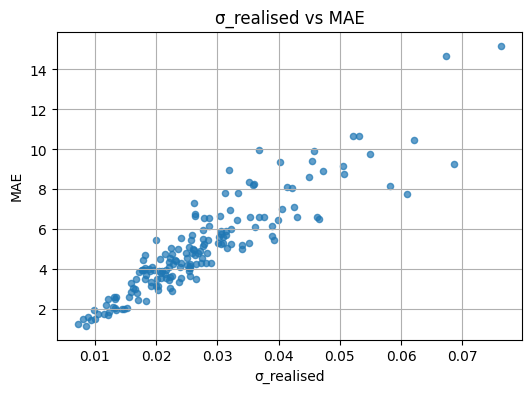

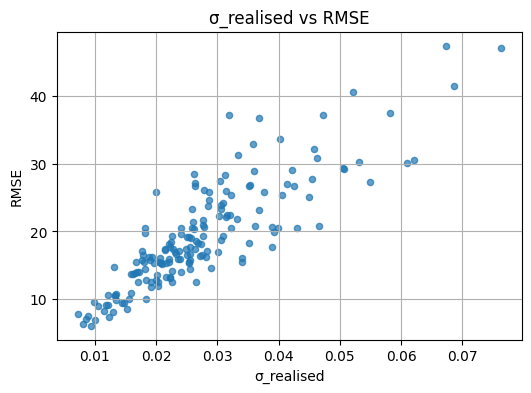

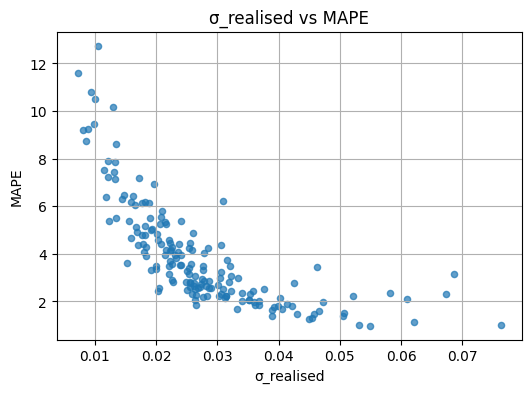

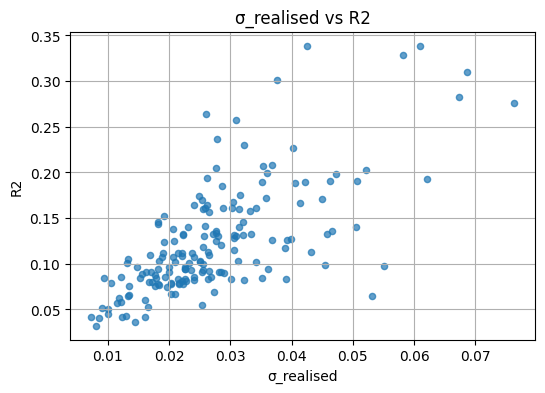

In [21]:
import matplotlib.pyplot as plt

# List of target columns to plot against σ_realised
y_cols = ["MAE", "RMSE", "MAPE", "R2"]

for y in y_cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(metrics_df["σ_realised"], metrics_df[y], s=20, alpha=0.7)
    ax.set_xlabel("σ_realised")
    ax.set_ylabel(y)
    ax.set_title(f"σ_realised vs {y}")
    ax.grid(True)
    plt.show()

In [5]:
from itertools import product
import pandas as pd, numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_volume_model(trades_df, halflife, lookahead, return_series=False):
    """给定 halflife & lookahead 计算误差，return_series=True 时额外返回 pred/true 序列"""
    if trades_df.empty:            # 安全短路
        return None if not return_series else (None, None, None)

    trades_df = trades_df.copy()
    trades_df["datetime"] = pd.to_datetime(trades_df["ts"], unit="ms", utc=True)
    trades = trades_df.set_index("datetime").sort_index()
    trades["vol"] = trades["v"].abs()

    vol_1s   = trades["vol"].resample("1s").sum().fillna(0)
    if len(vol_1s) < lookahead:    # 秒桶不足
        return None if not return_series else (None, None, None)

    pred_vol = vol_1s.ewm(halflife=halflife, adjust=False).mean()
    true_vol = (vol_1s
                .rolling(lookahead, min_periods=lookahead)
                .sum()
                .shift(-(lookahead-1)))

    df_eval = pd.DataFrame({"pred": pred_vol, "true": true_vol}).dropna()
    if df_eval.empty:
        return None if not return_series else (None, None, None)

    metrics = {
        "samples": len(df_eval),
        "MAE":  mean_absolute_error(df_eval["true"], df_eval["pred"]),
        "RMSE": mean_squared_error(df_eval["true"], df_eval["pred"], squared=False),
        "MAPE": (np.abs(df_eval["true"]-df_eval["pred"])
                 / df_eval["true"].replace(0, np.nan)).mean(),
        "R2":   r2_score(df_eval["true"], df_eval["pred"]),
    }
    if return_series:
        return metrics, df_eval["pred"], df_eval["true"]
    return metrics


In [ ]:
import filegetter.filegetter as fgt
from datetime import datetime
import matplotlib.pyplot as plt

HALFLIFES   = list(range(5, 65, 5))     # 5,10,…,60
LOOKAHEADS  = [1, 2, 3, 4, 5]

dates       = pd.date_range("2024-01-01", "2024-06-22", freq="D")
best_rows   = []        # 记录最佳指标

for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = fgt.get("binance", "swap", "btc-usdt", "trade", ymd, machine="AWS-JP1")
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")
        continue

    # 基础清洗
    cols = ["p", "v", "ts"]
    if not set(cols).issubset(raw.columns):
        print(f"[SKIP] {ymd}: missing columns")
        continue
    raw = raw[cols].dropna(subset=cols)
    if raw.empty:
        print(f"[SKIP] {ymd}: empty after NaN drop")
        continue

    # —— 网格搜索 —— #
    best_m, best_hl, best_la = None, None, None
    for hl, la in product(HALFLIFES, LOOKAHEADS):
        m = evaluate_volume_model(raw, hl, la)
        if m is None:          # 样本不足
            continue
        if (best_m is None) or (m["R2"] > best_m["R2"]):    # ← 以 R² 为目标
            best_m, best_hl, best_la = m, hl, la
    if best_m is None:
        print(f"[SKIP] {ymd}: no valid hyper-pair")
        continue

    # 保存最佳指标
    sigma = daily_realized_vol(raw)
    best_rows.append({
        "date": ymd,
        "σ_realised": sigma,
        "halflife": best_hl,
        "lookahead": best_la,
        **best_m,
    })

best_metrics_df = pd.DataFrame(best_rows).sort_values("date")


loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_01.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_02.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_03.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_04.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_05.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_06.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_07.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_08.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_09.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_10.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_11.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_12.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_13.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_14.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_15.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_

/home/luchen/filegetter-1/.venv/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/luchen/filegetter-1/.venv/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/luchen/filegetter-1/.venv/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/luchen/filegetter-1/.venv/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/luchen/filegetter-1/.venv/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMet

loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_03.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_04.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_05.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_06.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_07.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_08.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_09.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_10.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_11.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_12.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_13.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_14.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_15.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_16.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_17.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_

In [9]:
best_metrics_df

,date,σ_realised,halflife,lookahead,samples,MAE,RMSE,MAPE,R2
0,20240101,0.017661,5,1,86402,2.416542,8.916790,19.363575,0.294224
1,20240102,0.031195,5,1,86401,4.626949,14.650619,8.853705,0.346322
2,20240103,0.068695,5,1,86398,4.861196,18.085985,11.529185,0.579197
3,20240104,0.030647,5,1,86403,3.502796,12.113210,13.177624,0.377191
4,20240105,0.046326,5,1,86401,3.802155,14.111839,13.908164,0.479799
...,...,...,...,...,...,...,...,...,...
167,20240618,0.030555,5,1,86401,3.392743,12.092490,17.925887,0.361229
168,20240619,0.016563,5,1,86399,1.856266,8.202865,22.458457,0.244763
169,20240620,0.018887,5,1,86400,2.455803,9.109997,20.722364,0.309235
170,20240621,0.021498,5,1,86403,2.262256,8.547069,18.791173,0.382541


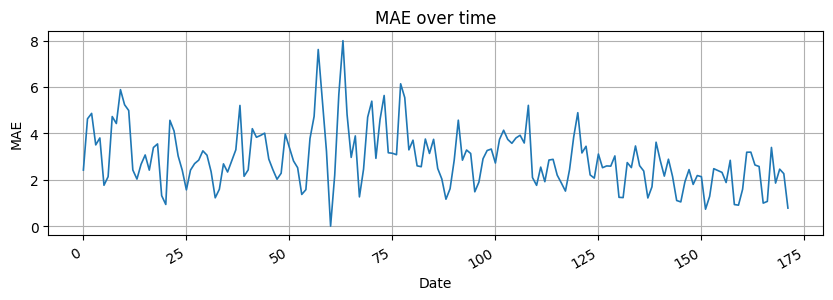

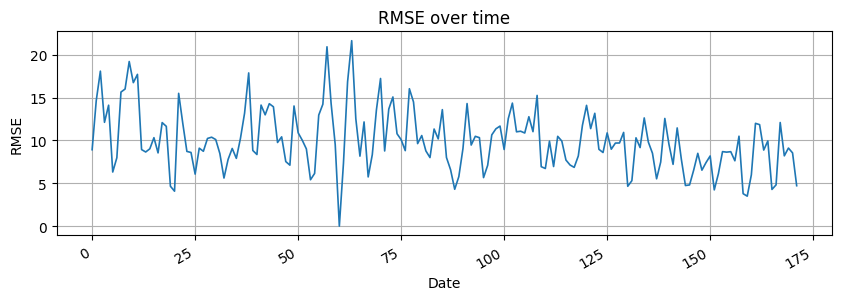

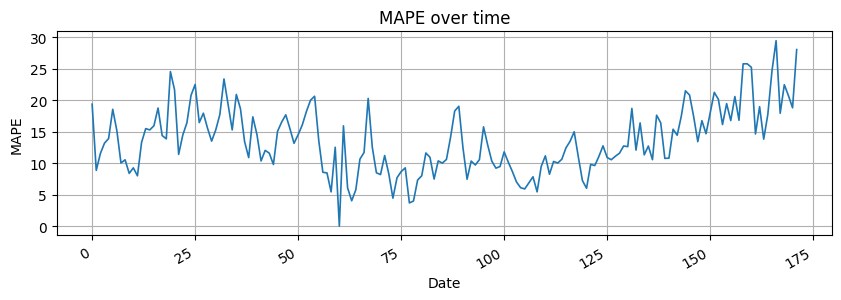

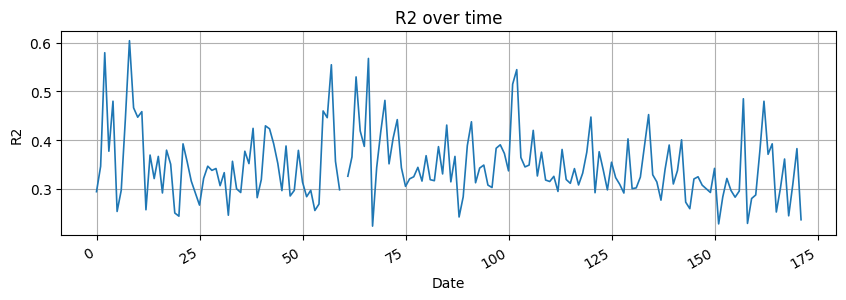

In [25]:
# Metrics to plot
y_cols = ["MAE", "RMSE", "MAPE", "R2"]

for y in y_cols:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(best_metrics_df.index, best_metrics_df[y], linewidth=1.2)
    ax.set_xlabel("Date")
    ax.set_ylabel(y)
    ax.set_title(f"{y} over time")
    ax.grid(True)
    # Improve date formatting (rotate labels)
    fig.autofmt_xdate()
    plt.show()

In [16]:
series_bank = {}
for _, row in best_metrics_df.iterrows():
    ymd = str(row["date"])            # 20240109 → "20240109"
    try:
        raw = fgt.get("binance", "swap", "btc-usdt", "trade", ymd, machine="AWS-JP1")
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")
        continue

    raw = raw[["p","v","ts"]].dropna()
    _, pred_s, true_s = evaluate_volume_model(
        raw,
        halflife=int(row["halflife"]),
        lookahead=int(row["lookahead"]),
        return_series=True
    )
    if pred_s is not None:            # 数据有效才保存
        series_bank[int(ymd)] = (pred_s, true_s)      # 用 int 键更稳妥


loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_01.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_02.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_03.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_04.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_05.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_06.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_07.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_08.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_09.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_10.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_11.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_12.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_13.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_14.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_15.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_

/home/luchen/filegetter-1/.venv/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_04.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_05.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_06.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_07.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_08.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_09.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_10.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_11.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_12.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_13.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_14.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_15.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_16.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_17.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_18.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_03_

In [18]:
series_bank


{20240101: (datetime
  2023-12-31 23:59:58+00:00    0.900000
  2023-12-31 23:59:59+00:00    0.938188
  2024-01-01 00:00:00+00:00    1.026577
  2024-01-01 00:00:01+00:00    0.893687
  2024-01-01 00:00:02+00:00    0.778000
                                 ...   
  2024-01-01 23:59:55+00:00    3.156613
  2024-01-01 23:59:56+00:00    2.937376
  2024-01-01 23:59:57+00:00    2.620953
  2024-01-01 23:59:58+00:00    2.481412
  2024-01-01 23:59:59+00:00    2.289256
  Freq: S, Name: pred, Length: 86402, dtype: float64,
  datetime
  2023-12-31 23:59:58+00:00    0.900
  2023-12-31 23:59:59+00:00    1.195
  2024-01-01 00:00:00+00:00    1.621
  2024-01-01 00:00:01+00:00    0.000
  2024-01-01 00:00:02+00:00    0.000
                               ...  
  2024-01-01 23:59:55+00:00    7.414
  2024-01-01 23:59:56+00:00    1.463
  2024-01-01 23:59:57+00:00    0.493
  2024-01-01 23:59:58+00:00    1.543
  2024-01-01 23:59:59+00:00    0.997
  Freq: S, Name: true, Length: 86402, dtype: float64),
 20240102: (

In [21]:
day = 20240101
pred_s, true_s = series_bank[day] 
pred_s, true_s

(datetime
 2023-12-31 23:59:58+00:00    0.900000
 2023-12-31 23:59:59+00:00    0.938188
 2024-01-01 00:00:00+00:00    1.026577
 2024-01-01 00:00:01+00:00    0.893687
 2024-01-01 00:00:02+00:00    0.778000
                                ...   
 2024-01-01 23:59:55+00:00    3.156613
 2024-01-01 23:59:56+00:00    2.937376
 2024-01-01 23:59:57+00:00    2.620953
 2024-01-01 23:59:58+00:00    2.481412
 2024-01-01 23:59:59+00:00    2.289256
 Freq: S, Name: pred, Length: 86402, dtype: float64,
 datetime
 2023-12-31 23:59:58+00:00    0.900
 2023-12-31 23:59:59+00:00    1.195
 2024-01-01 00:00:00+00:00    1.621
 2024-01-01 00:00:01+00:00    0.000
 2024-01-01 00:00:02+00:00    0.000
                              ...  
 2024-01-01 23:59:55+00:00    7.414
 2024-01-01 23:59:56+00:00    1.463
 2024-01-01 23:59:57+00:00    0.493
 2024-01-01 23:59:58+00:00    1.543
 2024-01-01 23:59:59+00:00    0.997
 Freq: S, Name: true, Length: 86402, dtype: float64)

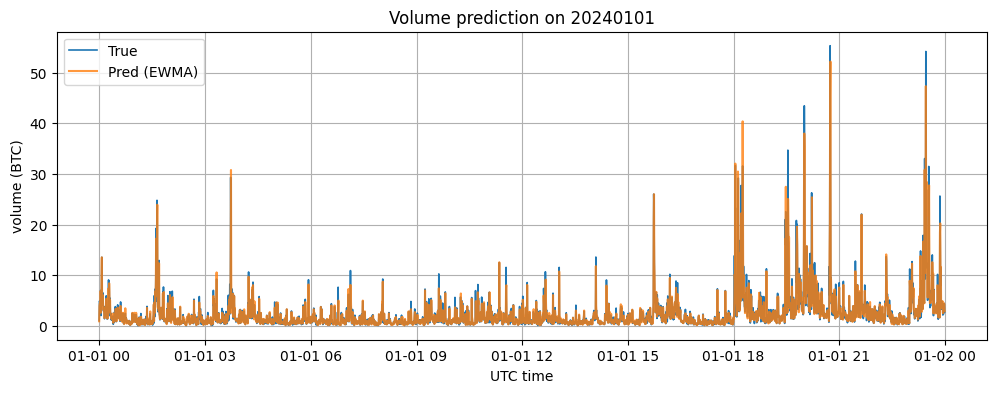

In [22]:
import matplotlib.pyplot as plt

resample_rule = "30s"      # 改成 "1min" 也行
plt.figure(figsize=(12, 4))
plt.plot(true_s.resample(resample_rule).mean(),
         label="True", linewidth=1.2)
plt.plot(pred_s.resample(resample_rule).mean(),
         label="Pred (EWMA)", alpha=0.8)
plt.title(f"Volume prediction on {day}")
plt.xlabel("UTC time")
plt.ylabel("volume (BTC)")
plt.legend()
plt.grid(True)
plt.show()


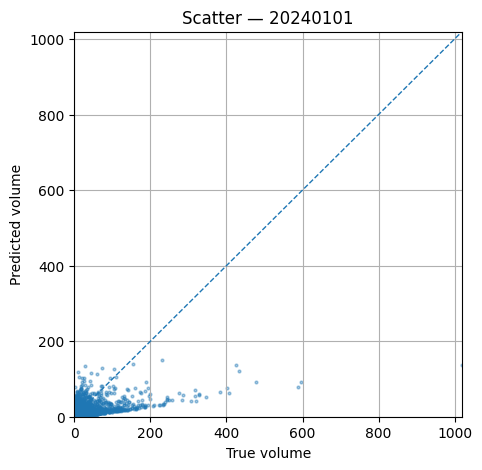

In [23]:
plt.figure(figsize=(5,5))
plt.scatter(true_s, pred_s, s=4, alpha=0.4)
lims = [0, max(true_s.max(), pred_s.max())]
plt.plot(lims, lims, "--", linewidth=1)      # 45° 参考线
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True volume")
plt.ylabel("Predicted volume")
plt.title(f"Scatter — {day}")
plt.grid(True)
plt.show()
